## Table of Contents

- Mount Drive & Install Dependencies
- Imports & Paths
- Hyperparameters
- PEFT Injector (unchanged)
- State Discretization with Trend
- Contextual Bandit Agent
- Forecast Loader (unchanged)
- Risk Metrics (unchanged)
- Main Execution – Load Forecasts & Prices
- Contextual Bandit Backtest
- Results & Metrics (Out-of-Sample)
- Additional Analysis

## Imports & Paths

In [17]:
import os
import sys
import json
import pickle
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from tqdm import tqdm
from types import SimpleNamespace

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from peft import LoraConfig, PeftModel, get_peft_model

# -------------------------------
# Set your paths here
# -------------------------------
BASE_DIR = "/content/drive/MyDrive/Prototype/fincast_rl_app"
MODEL_PATH = os.path.join(BASE_DIR, "models", "v1.pth")
ADAPTER_PATH = os.path.join(BASE_DIR, "models", "5min_adapter_2_continued_best")
DATA_PATH = os.path.join(BASE_DIR, "data", "PHDC_cleaned.csv")   # change as needed
FORECASTS_OUTPUT = os.path.join(BASE_DIR, "forecasts_PHDC_bandit_V2.npz")
Q_TABLE_PATH = os.path.join(BASE_DIR, "q_table_bandit_v2.pkl")

# Add FinCast src to path
sys.path.append(os.path.join(BASE_DIR, "src"))

print("✅ Paths set.")

✅ Paths set.


## Hyperparameters

In [2]:
CONTEXT_LEN = 128
HORIZON_LEN = 60
ALPHA = 0.3                 # Higher learning rate for bandit
EPSILON = 0.1
EPSILON_DECAY = 0.995
MIN_EPSILON = 0.01
TRANSACTION_COST = 0.0015
TEST_WINDOWS = 2000         # Increase if you have more data
TRAIN_RATIO = 0.7

## PEFT Injector 

In [3]:
from typing import List, Optional

def _default_targets(model: nn.Module, preset: str) -> List[str]:
    preset = preset.lower()
    if preset == "all_linear":
        names = []
        for name, module in model.named_modules():
            if isinstance(module, nn.Linear):
                names.append(name)
        return names
    if preset == "attn":
        return ["qkv_proj", "o_proj"]
    if preset == "attn_mlp":
        return [
            "qkv_proj", "o_proj",
            "input_ff_layer.hidden_layer.0",
            "input_ff_layer.output_layer",
            "horizon_ff_layer.hidden_layer.0",
            "horizon_ff_layer.output_layer",
        ]
    raise ValueError(f"Unknown preset: {preset}")

def resolve_linear_targets(model: nn.Module, patterns: List[str]) -> List[str]:
    hits = []
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            if any(p in name for p in patterns) or name in patterns:
                hits.append(name)
    return hits

def _freeze_all_params(model: nn.Module) -> None:
    for p in model.parameters():
        p.requires_grad = False

def wrap_with_peft(
    model: nn.Module,
    *,
    peft_type: Optional[str],
    lora_r: int,
    lora_alpha: int,
    lora_dropout: float,
    lora_bias: str,
    lora_init: Optional[str],
    lora_targets_preset: str,
    lora_extra_target_patterns: Optional[List[str]] = None,
    train_base: bool = False,
):
    if peft_type is None:
        return model
    use_dora = (peft_type.lower() == "dora")
    if peft_type.lower() not in ["lora", "dora"]:
        raise ValueError("peft_type must be one of: None, 'lora', 'dora'")
    patterns = _default_targets(model, lora_targets_preset)
    if lora_extra_target_patterns:
        patterns.extend(lora_extra_target_patterns)
    resolved = resolve_linear_targets(model, patterns)
    if not resolved:
        raise RuntimeError(f"No nn.Linear matched: {patterns}")
    if not train_base:
        _freeze_all_params(model)
    lora_kwargs = dict(
        r=lora_r,
        lora_alpha=lora_alpha,
        lora_dropout=lora_dropout,
        bias=lora_bias,
        target_modules=resolved,
        use_dora=use_dora,
    )
    if lora_init is not None:
        lora_kwargs["init_lora_weights"] = lora_init
    peft_cfg = LoraConfig(**lora_kwargs)
    peft_model = get_peft_model(model, peft_cfg)
    try:
        peft_model.print_trainable_parameters()
    except Exception:
        pass
    return peft_model

## State Discretization with Trend

In [4]:
def compute_trend(prices, window=10):
    if len(prices) < window:
        return 0.0
    x = np.arange(window)
    y = prices[-window:]
    slope = np.polyfit(x, y, 1)[0]
    return slope / prices[-1]

def discretize_state(point, q10, q90, current_price, price_history):
    expected_return = (point - current_price) / current_price
    spread = (q90 - q10) / current_price

    # Return bins (7)
    if expected_return < -0.04:
        ret_bin = "VeryDown"
    elif expected_return < -0.015:
        ret_bin = "Down"
    elif expected_return < -0.005:
        ret_bin = "SlightDown"
    elif expected_return < 0.005:
        ret_bin = "Flat"
    elif expected_return < 0.015:
        ret_bin = "SlightUp"
    elif expected_return < 0.04:
        ret_bin = "Up"
    else:
        ret_bin = "VeryUp"

    # Volatility bins (3)
    if spread < 0.01:
        vol_bin = "LowVol"
    elif spread < 0.03:
        vol_bin = "MidVol"
    else:
        vol_bin = "HighVol"

    # Confidence bins (2)
    if spread < 0.01:
        conf_bin = "HighConf"
    else:
        conf_bin = "LowConf"

    # Trend (3)
    trend = compute_trend(price_history, window=10)
    if trend > 0.001:
        trend_bin = "TrendUp"
    elif trend < -0.001:
        trend_bin = "TrendDown"
    else:
        trend_bin = "TrendFlat"

    return f"{ret_bin}_{vol_bin}_{conf_bin}_{trend_bin}"

## Contextual Bandit Agent

In [5]:
class BanditAgent:
    def __init__(self, alpha=0.3, epsilon=0.1, epsilon_decay=0.995, min_epsilon=0.01):
        self.q_table = defaultdict(lambda: {"BUY": 0.0, "HOLD": 0.0, "SELL": 0.0})
        self.alpha = alpha
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.min_epsilon = min_epsilon
        self.actions = ["BUY", "HOLD", "SELL"]

    def act(self, state, greedy=False):
        if not greedy and random.random() < self.epsilon:
            return random.choice(self.actions)
        return max(self.q_table[state], key=self.q_table[state].get)

    def learn(self, state, action, reward):
        """Bandit update: Q(s,a) += alpha * (reward - Q(s,a))"""
        self.q_table[state][action] += self.alpha * (reward - self.q_table[state][action])
        self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay)

    def save(self, path):
        with open(path, 'wb') as f:
            pickle.dump(dict(self.q_table), f)

    def load(self, path):
        with open(path, 'rb') as f:
            data = pickle.load(f)
            self.q_table = defaultdict(lambda: {"BUY": 0.0, "HOLD": 0.0, "SELL": 0.0}, data)

## Forecast Loader

In [16]:
from tools.inference_utils import FinCast_Inference

def extract_prediction(preds, horizon_len):
    if preds.ndim == 4:
        preds = preds[..., 0]
        return preds[:, -1, :horizon_len]
    elif preds.ndim == 3:
        return preds[:, 0, :horizon_len]
    elif preds.ndim == 2:
        return preds[:, :horizon_len]
    raise RuntimeError(f"Unexpected preds shape: {preds.shape}")

def load_forecasts(csv_path, model_path, adapter_path, context_len, horizon_len, max_windows=None):
    print(f"🚀 Using device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")
    print(f"📂 Data: {os.path.basename(csv_path)}")
    print(f"📊 Context: {context_len} | Horizon: {horizon_len}")
    print("=" * 60)

    # --- Load base model ---
    print("📌 Loading base FinCast model...")
    start_total = time.time()
    config = SimpleNamespace(
        backend='gpu' if torch.cuda.is_available() else 'cpu',
        model_path=model_path,
        model_version='v1',
        data_path=csv_path,
        data_frequency='m',
        context_len=context_len,
        horizon_len=horizon_len,
        columns_target=['close'],
        batch_size=1,
        forecast_mode='mean',
        save_output=False,
        save_output_path='',
        plt_outputs=False,
        plt_quantiles=[1, 9],
        series_norm=True,
        dropna=True,
        all_data=True,
    )
    fincast_inf = FinCast_Inference(config)
    base_model = fincast_inf.model_api._model
    print(f"✅ Base model loaded. ({time.time() - start_total:.2f}s)")

    # --- Load adapter ---
    print("📌 Loading fine‑tuned adapter...")
    start_adapter = time.time()
    config_path = os.path.join(adapter_path, "adapter_config.json")
    with open(config_path, "r") as f:
        full_config = json.load(f)

    VALID_LORA_KEYS = {
        'r', 'lora_alpha', 'target_modules', 'lora_dropout', 'bias',
        'task_type', 'inference_mode', 'init_lora_weights', 'use_rslora'
    }
    filtered_config = {k: v for k, v in full_config.items() if k in VALID_LORA_KEYS}
    peft_config = LoraConfig(**filtered_config)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = PeftModel.from_pretrained(base_model, adapter_path, config=peft_config)
    model.to(device)
    model.eval()
    print(f"✅ Adapter loaded and applied. ({time.time() - start_adapter:.2f}s)")

    # --- Replace model in inference object ---
    fincast_inf.model_api._model = model

    # --- Get dataset and extract normalization parameters ---
    dataset = fincast_inf.inference_dataset
    # Try to get the scaler/mean/std
    # Common pattern: dataset.scaler or dataset.mean, dataset.std
    if hasattr(dataset, 'scaler'):
        scaler = dataset.scaler
        if hasattr(scaler, 'mean_') and hasattr(scaler, 'scale_'):
            mean = scaler.mean_[0]   # assuming single target
            std = scaler.scale_[0]
        else:
            # Fallback: compute from the dataset
            all_data = []
            for i in range(len(dataset)):
                x, _, _ = dataset[i]
                # x is (seq_len, features), we need the target column
                target_idx = 0  # assuming 'close' is first column
                all_data.extend(x[:, target_idx].numpy())
            mean = np.mean(all_data)
            std = np.std(all_data)
    elif hasattr(dataset, 'mean') and hasattr(dataset, 'std'):
        mean = dataset.mean
        std = dataset.std
    else:
        # Fallback: compute from entire price series
        # Load the full dataframe to compute
        df = pd.read_csv(csv_path)
        close = df['close'].values
        mean = np.mean(close)
        std = np.std(close)

    print(f"📊 Normalization parameters: mean={mean:.4f}, std={std:.4f}")

    # --- Limit windows ---
    if max_windows is not None and max_windows < len(dataset):
        dataset = Subset(dataset, range(max_windows))
        print(f"📊 Using first {max_windows} windows (out of {len(dataset)})")
    else:
        print(f"📊 Total windows: {len(dataset)}")

    loader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=0)

    # --- Custom inference loop with denormalization ---
    print("🚀 Running inference (one window at a time)...")
    start_inference = time.time()

    point_list = []
    q10_list = []
    q90_list = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Inference", unit="window"):
            x = batch[0].to(device)
            x_pad = batch[1].to(device)
            freq = batch[2].to(device)

            out = model(x, x_pad.float(), freq)
            preds = out[0] if isinstance(out, tuple) else out

            pred_final = extract_prediction(preds, horizon_len)
            # pred_final is normalized; denormalize to price
            point_norm = pred_final[0, -1].item()
            point_price = point_norm * std + mean

            if preds.shape[-1] >= 10:
                q10_norm = preds[0, -1, -1, 1].item()
                q90_norm = preds[0, -1, -1, 9].item()
                q10 = q10_norm * std + mean
                q90 = q90_norm * std + mean
            else:
                q10 = point_price * 0.995
                q90 = point_price * 1.005

            point_list.append(point_price)
            q10_list.append(q10)
            q90_list.append(q90)

    elapsed = time.time() - start_inference
    print(f"✅ Inference completed in {elapsed:.2f}s ({elapsed/60:.2f} min)")

    point = np.array(point_list)
    q10 = np.array(q10_list)
    q90 = np.array(q90_list)

    total_time = time.time() - start_total
    print(f"📊 Forecasts extracted: {len(point)} windows")
    print(f"⏱️ Total time: {total_time:.2f}s ({total_time/60:.2f} min)")
    print("=" * 60)

    return point, q10, q90

## Risk Metrics

In [7]:
def compute_metrics(returns, benchmark_returns=None):
    ret = np.array(returns)
    if len(ret) == 0:
        return {}
    mean_ret = np.mean(ret)
    std_ret = np.std(ret) if len(ret) > 1 else 0.0
    ann_factor = 252
    sharpe = mean_ret / std_ret * np.sqrt(ann_factor) if std_ret > 0 else 0.0
    cum_ret = np.cumprod(1 + ret) - 1 if len(ret) > 0 else 0.0
    running_max = np.maximum.accumulate(np.cumprod(1 + ret))
    drawdown = (np.cumprod(1 + ret) / running_max) - 1
    max_drawdown = np.min(drawdown) if len(drawdown) > 0 else 0.0
    win_rate = np.mean(ret > 0) if len(ret) > 0 else 0.0
    calmar = cum_ret / abs(max_drawdown) if max_drawdown < 0 else np.inf
    downside_ret = ret[ret < 0]
    if len(downside_ret) > 0:
        downside_std = np.std(downside_ret)
        sortino = mean_ret / downside_std * np.sqrt(ann_factor) if downside_std > 0 else np.inf
    else:
        sortino = np.inf
    if benchmark_returns is not None:
        excess_ret = cum_ret - (np.cumprod(1 + np.array(benchmark_returns)) - 1)
    else:
        excess_ret = 0.0
    return {
        "mean_return": mean_ret,
        "std_return": std_ret,
        "cumulative_return": cum_ret,
        "sharpe_ratio": sharpe,
        "max_drawdown": max_drawdown,
        "win_rate": win_rate,
        "calmar_ratio": calmar,
        "sortino_ratio": sortino,
        "excess_return": excess_ret,
    }

## Main Execution – Load Forecasts & Prices

In [18]:
# Load or generate forecasts
if os.path.exists(FORECASTS_OUTPUT):
    data = np.load(FORECASTS_OUTPUT)
    point, q10, q90 = data['point'], data['q10'], data['q90']
    print("✅ Forecasts loaded from disk.")
else:
    point, q10, q90 = load_forecasts(
        DATA_PATH,
        MODEL_PATH,
        ADAPTER_PATH,
        CONTEXT_LEN,
        HORIZON_LEN,
        max_windows=TEST_WINDOWS
    )
    np.savez_compressed(FORECASTS_OUTPUT, point=point, q10=q10, q90=q90)

forecasts = {'point': point, 'q10': q10, 'q90': q90}

# Load price data
df = pd.read_csv(DATA_PATH)
close = df['close'].values
print(f"📈 Loaded {len(close)} price points from {os.path.basename(DATA_PATH)}")

🚀 Using device: cuda
📂 Data: PHDC_cleaned.csv
📊 Context: 128 | Horizon: 60
📌 Loading base FinCast model...
✅ Base model loaded. (22.30s)
📌 Loading fine‑tuned adapter...
✅ Adapter loaded and applied. (0.43s)
📊 Normalization parameters: mean=10.0397, std=2.2513
📊 Using first 2000 windows (out of 2000)
🚀 Running inference (one window at a time)...


Inference: 100%|██████████| 2000/2000 [07:39<00:00,  4.35window/s]

✅ Inference completed in 459.48s (7.66 min)
📊 Forecasts extracted: 2000 windows
⏱️ Total time: 482.23s (8.04 min)
📈 Loaded 5236 price points from PHDC_cleaned.csv


## Contextual Bandit Backtest

📊 Total windows: 2000, Training: 1400, Test: 600

🚀 Running Contextual Bandit Backtest...


Backtesting: 100%|██████████| 2000/2000 [00:00<00:00, 9760.04it/s] 


💾 Q‑table saved to /content/drive/MyDrive/Prototype/fincast_rl_app/q_table_bandit_v2.pkl

Algo                   OOS return   Sharpe     Max DD    Edge vs B&H
----------------------------------------------------------------------
Bandit (FinCast)            8.3%     0.83      -1.9%          0.7%
✅ Plot saved to bandit_results.png


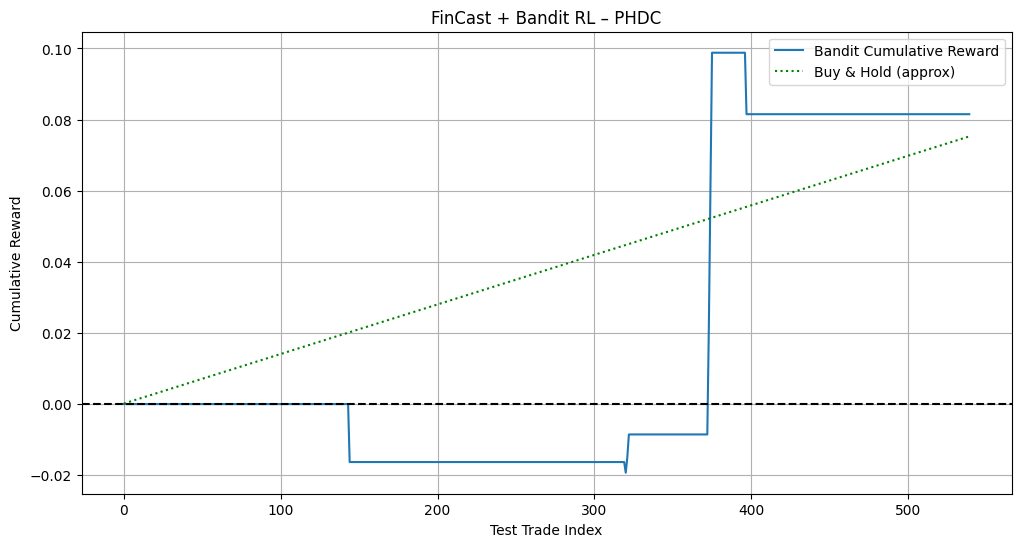

In [19]:
# ------------------------------------------------------------
# 10. Contextual Bandit Backtest (Delayed Reward)
# ------------------------------------------------------------
n = len(close)
total_len = CONTEXT_LEN + HORIZON_LEN
max_windows = min(TEST_WINDOWS, n - total_len)
train_split = int(max_windows * TRAIN_RATIO)

print(f"📊 Total windows: {max_windows}, Training: {train_split}, Test: {max_windows - train_split}")

# Initialize fresh agent
agent = BanditAgent(alpha=ALPHA, epsilon=EPSILON,
                    epsilon_decay=EPSILON_DECAY,
                    min_epsilon=MIN_EPSILON)

# Load pre-trained Q-table if exists
if os.path.exists(Q_TABLE_PATH):
    agent.load(Q_TABLE_PATH)
    print(f"📂 Loaded Q-table from {Q_TABLE_PATH}")

# History to store actions and states for delayed reward
history = {}

# Collectors for metrics
all_actions = []
all_states = []
all_test_rewards = []   # rewards for trades that were initiated in test period

print("\n🚀 Running Contextual Bandit Backtest...")
for i in tqdm(range(max_windows), desc="Backtesting"):
    # --- 1. Get current state and decide action ---
    context = close[i:i+CONTEXT_LEN]
    current_price = close[i+CONTEXT_LEN-1]

    point_val = forecasts['point'][i]
    q10_val = forecasts['q10'][i]
    q90_val = forecasts['q90'][i]
    state = discretize_state(point_val, q10_val, q90_val, current_price, context)

    is_train = (i < train_split)
    action = agent.act(state, greedy=(not is_train))

    # Store decision
    history[i] = {'state': state, 'action': action, 'price': current_price}
    all_actions.append(action)
    all_states.append(state)

    # --- 2. Evaluate a trade that closed today (i - HORIZON_LEN) ---
    if i >= HORIZON_LEN:
        past_i = i - HORIZON_LEN
        past_data = history[past_i]
        past_state = past_data['state']
        past_action = past_data['action']
        past_price = past_data['price']
        future_price = current_price  # price at close

        if past_action == "BUY":
            reward = (future_price - past_price) / past_price - TRANSACTION_COST * 2
        elif past_action == "SELL":
            reward = (past_price - future_price) / past_price - TRANSACTION_COST * 2
        else:
            reward = 0.0

        # Learn only if the trade was initiated during training period
        if past_i < train_split:
            agent.learn(past_state, past_action, reward)

        # Record reward if the trade was initiated during test period
        if past_i >= train_split:
            all_test_rewards.append(reward)

# Save Q-table after training
agent.save(Q_TABLE_PATH)
print(f"💾 Q‑table saved to {Q_TABLE_PATH}")

# ------------------------------------------------------------
# 11. Results & Metrics (Out‑of‑Sample)
# ------------------------------------------------------------
if len(all_test_rewards) > 0:
    test_rewards = np.array(all_test_rewards)
    compounded = np.prod(1 + test_rewards) - 1
    metrics = compute_metrics(test_rewards)

    # ---- Correct buy-and-hold for the exact test period ----
    # The test period starts at train_split and ends at max_windows-1
    first_test_idx = train_split + CONTEXT_LEN - 1
    last_test_idx = max_windows + CONTEXT_LEN - 2
    # Safety clamp to avoid index out of bounds
    last_test_idx = min(len(close) - 1, last_test_idx)
    bh_return = (close[last_test_idx] - close[first_test_idx]) / close[first_test_idx]
    bh_rewards = np.full(len(test_rewards), bh_return / len(test_rewards))

    # Print table
    print("\n" + "="*70)
    print(f"{'Algo':<20} {'OOS return':>12} {'Sharpe':>8} {'Max DD':>10} {'Edge vs B&H':>14}")
    print("-"*70)
    print(f"{'Bandit (FinCast)':<20} {compounded:>11.1%} {metrics['sharpe_ratio']:>8.2f} {metrics['max_drawdown']:>10.1%} {compounded - bh_return:>13.1%}")
    print("="*70)

    # Plot cumulative
    plt.figure(figsize=(12, 6))
    plt.plot(np.cumsum(test_rewards), label='Bandit Cumulative Reward')
    plt.axhline(y=0, color='black', linestyle='--')
    plt.plot(np.cumsum(bh_rewards), label='Buy & Hold (approx)', linestyle=':', color='green')
    plt.xlabel('Test Trade Index')
    plt.ylabel('Cumulative Reward')
    plt.title(f'FinCast + Bandit RL – {os.path.basename(DATA_PATH).split("_")[0]}')
    plt.legend()
    plt.grid(True)
    plt.savefig('bandit_results_V2.png')
    print("✅ Plot saved to bandit_results.png")
else:
    print("⚠️ No test trades completed. Increase TEST_WINDOWS or check forecast availability.")

## Results & Metrics (Out-of-Sample)

## Additional Analysis

✅ Plot with trades saved to bandit_trades.png


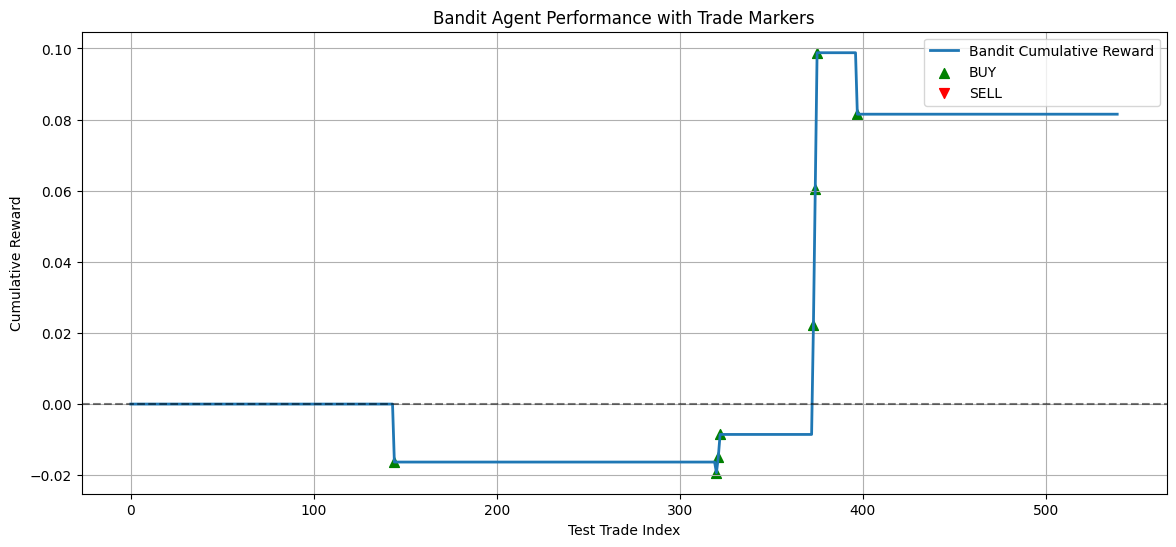

In [24]:
# Plot cumulative return with trade markers
plt.figure(figsize=(14, 6))
plt.plot(np.cumsum(test_rewards), label='Bandit Cumulative Reward', linewidth=2)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)

# Mark buy/sell points
buy_points = [i for i, a in enumerate(test_actions) if a == 'BUY']
sell_points = [i for i, a in enumerate(test_actions) if a == 'SELL']
cumulative = np.cumsum(test_rewards)

plt.scatter(buy_points, cumulative[buy_points], color='green', marker='^', label='BUY', s=50)
plt.scatter(sell_points, cumulative[sell_points], color='red', marker='v', label='SELL', s=50)

plt.xlabel('Test Trade Index')
plt.ylabel('Cumulative Reward')
plt.title('Bandit Agent Performance with Trade Markers')
plt.legend()
plt.grid(True)
plt.savefig('bandit_trades.png')
print("✅ Plot with trades saved to bandit_trades.png")